In [64]:
import numpy as np
from numpy.linalg import norm, solve, LinAlgError
import matplotlib.pyplot as plt
from case_studies import * 


ModuleNotFoundError: No module named 'case_studies'

In [65]:
import numpy as np

def find_optimal_x(Q, b, Delta, epsilon):
    """Finds the optimal feasible x* exactly as described in the algorithm."""
    
    def compute_p(Q, lambda_val, g):
        """Computes p(lambda) = -(Q + lambda * I)^(-1) * g."""
        n = Q.shape[0]
        I = np.eye(n)
        return -np.linalg.inv(Q + lambda_val * I) @ g
    
    lambda_1_Q = np.linalg.eigvalsh(Q)[0]  # Smallest eigenvalue of Q
    
    # Compute p(0)
    p_0 = compute_p(Q, 0, b)
    
    # Check initial condition
    if lambda_1_Q > 0 and np.linalg.norm(p_0) <= Delta:
        return p_0, 0  # Return x* and lambda* (lambda* = 0 in this case)
    
    # Initialize l and u
    l = max(0, -lambda_1_Q)
    u = max(0, -lambda_1_Q) + 1
    
    # Expand u until ||p(u)|| > Delta
    while np.linalg.norm(compute_p(Q, u, b)) > Delta:
        l = u
        u = 2 * u
    
    # Binary search
    while True:
        lambda_prime = 0.5 * (l + u)
        p_prime = compute_p(Q, lambda_prime, b)
        norm_p_prime = np.linalg.norm(p_prime)
        
        if norm_p_prime < Delta and abs(norm_p_prime - Delta) < epsilon:
            return p_prime, lambda_prime  # Now returning (x*, lambda*)
        
        if norm_p_prime > Delta:
            l = lambda_prime
        else:
            u = lambda_prime


#Take KKT from last week
def check_KKT(Q, b, Delta, x, lam, tol=1e-6):
    """Check the KKT conditions for the trust-region subproblem.
   The KKT conditions are:
      1) Stationarity:
            ∇f(x) + Σ_{j in I} λ_j * ∇c_j(x) + Σ_{i in E} μ_i * ∇c_i(x) = 0.
      2) Complementarity:
            For each j in I:  λ_j * c_j(x) = 0.
      3) Inequality feasibility:
            For each j in I:  c_j(x) ≤ 0.
      4) Equality feasibility:
            For each i in E:  c_i(x) = 0.
      5) Dual feasibility:
            For each j in I:  λ_j ≥ 0

    Returns a dictionary with residuals.
   """
    # Stationarity should be 0
    stationarity_resid = norm((Q + 2*lam*np.eye(Q.shape[0])).dot(x) + b)
    # Complementarity should be  0
    comp_resid = abs(lam * (norm(x)**2 - Delta**2))
    # Inequality constraint should be ≤ 0
    ineq_feas = norm(x) ** 2 - Delta ** 2 <= 0 
    # Equality feasibility should be the same condition
    equal_feas = abs(norm(x) ** 2 - Delta ** 2) <= tol
    # Dual feasibility should ensure lambda is non-negative
    dual_feas = lam >= -tol  # allow slight numerical negative drift
    
    return {
        'stationarity': stationarity_resid,
        'complementarity': comp_resid,
        'ineq_feasibility': ineq_feas,
        'equal_feasibility': equal_feas,
        'dual_feasibility': dual_feas
    }
    



,Test Case,x*,Lambda*,Iterations,Stationarity Residual,Complementarity Residual,Inequality Feasibility,Equality Feasibility,Dual Feasibility,Error Message
0,"Feasible Unconstrained (Δ=0.8, b=[0.5 0.5], ε=...","[-0.25, -0.25]",0.000000,None,0.000000,0.000000e+00,True,False,True,None
1,"Feasible Unconstrained (Δ=0.8, b=[0.5 0.5], ε=...","[-0.25, -0.25]",0.000000,None,0.000000,0.000000e+00,True,False,True,None
2,"Feasible Unconstrained (Δ=1.0, b=[0.5 0.5], ε=...","[-0.25, -0.25]",0.000000,None,0.000000,0.000000e+00,True,False,True,None
3,"Feasible Unconstrained (Δ=1.0, b=[0.5 0.5], ε=...","[-0.25, -0.25]",0.000000,None,0.000000,0.000000e+00,True,False,True,None
4,"Feasible Unconstrained (Δ=1.5, b=[0.5 0.5], ε=...","[-0.25, -0.25]",0.000000,None,0.000000,0.000000e+00,True,False,True,None
...,...,...,...,...,...,...,...,...,...,...
91,"Negative Definite Q (Δ=0.8, b=[-2. -2.], ε=1e-10)","[0.5656854249447769, 0.5656854249447769]",4.535534,None,3.628427,4.578436e-11,True,True,True,None
92,"Negative Definite Q (Δ=1.0, b=[-2. -2.], ε=1e-06)","[0.7071064952650563, 0.7071064952650563]",3.828428,None,3.828427,3.096080e-06,True,True,True,None
93,"Negative Definite Q (Δ=1.0, b=[-2. -2.], ε=1e-10)","[0.7071067811809711, 0.7071067811809711]",3.828427,None,3.828427,6.038385e-11,True,True,True,None
94,"Negative Definite Q (Δ=1.5, b=[-2. -2.], ε=1e-06)","[1.0606601005252845, 1.0606601005252845]",2.885618,None,4.328427,8.723437e-07,True,True,True,None


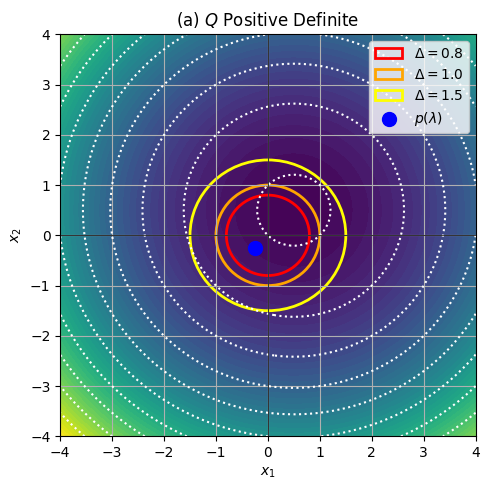

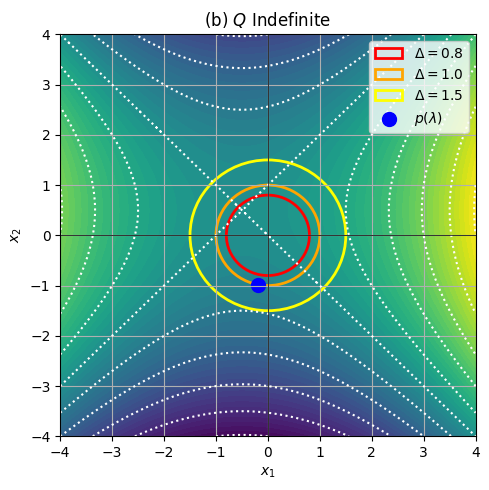

In [68]:
import numpy as np
import pandas as pd
from itertools import product  # To generate all test case combinations
from IPython.display import display

def run_tests():
    tests = []
    
    # Define test cases with different Q matrices
    base_tests = [
        ('Feasible Unconstrained', np.array([[2.0, 0.0], [0.0, 2.0]])),
        ('Active Constraint', np.array([[2.0, 0.0], [0.0, 2.0]])),
        ('Indefinite Q', np.array([[1.0, 0.0], [0.0, -1.0]])),
        ('Negative Definite Q', -np.array([[1.0, 0.0], [0.0, 1.0]]))
    ]
    
    # Different values of Delta, b, and epsilon to test
    delta_values = [0.8, 1.0, 1.5]
    b_values = [np.array([0.5, 0.5]), np.array([1.0, 1.0]), np.array([-1.0, -1.0]), np.array([-2.0, -2.0])]
    epsilon_values = [1e-6, 1e-10] 

    # Generate all combinations of test cases, Delta, b, and epsilon
    for (name, Q), b, Delta, epsilon in product(base_tests, b_values, delta_values, epsilon_values):
        tests.append((f"{name} (Δ={Delta}, b={b}, ε={epsilon})", Q, b, Delta, epsilon))

    results = []
    
    for name, Q, b, Delta, epsilon in tests:
        try:
            # Run the algorithm
            output = find_optimal_x(Q, b, Delta, epsilon)
            
            # Ensure `find_optimal_x` returns a tuple (x_star, lambda_star)
            if isinstance(output, tuple) and len(output) == 2:
                x_star, lambda_star = output
            else:
                raise ValueError("find_optimal_x must return (x_star, lambda_star)")
            
            # Check KKT conditions
            kkt_residuals = check_KKT(Q, b, Delta, x_star, lambda_star)

            # Ensure iter_count is defined and updated in find_optimal_x
            if 'iter_count' in locals() or 'iter_count' in globals():
                iteration_count = iter_count.get('iteration', None)
            else:
                iteration_count = None  # Default to None if iter_count is not defined

            results.append((
                name,
                x_star,
                lambda_star,
                iteration_count,
                kkt_residuals['stationarity'],
                kkt_residuals['complementarity'],
                kkt_residuals['ineq_feasibility'],
                kkt_residuals['equal_feasibility'],
                kkt_residuals['dual_feasibility'],
                None  # No error
            ))
        except Exception as e:
            results.append((
                name, None, None, None, None, None, None, None, str(e)  # Always 9 elements
            ))

    # Convert to DataFrame
    global df_results  # Declare df_results as global
    df_results = pd.DataFrame(results, columns=[
        'Test Case', 'x*', 'Lambda*', 'Iterations', 'Stationarity Residual',
        'Complementarity Residual', 'Inequality Feasibility',
        'Equality Feasibility', 'Dual Feasibility', 'Error Message'
    ])

    display(df_results)

# Run the test cases
run_tests()

# Ensure `df_results` is defined before this line
if 'df_results' not in locals():
    raise NameError("df_results is not defined. Ensure that `run_tests()` generates and assigns it.")

df_results["Delta"] = pd.to_numeric(df_results["Test Case"].str.extract(r'Δ=(\d+\.\d+)')[0])



def plot_quadratic_contours(Q, b, Delta_values, x_star, title, filename):
    """Generate a single contour plot showing multiple Delta constraints."""
    
    x_range = np.linspace(-4, 4, 100)
    y_range = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(x_range, y_range)

    # Compute function values
    Z = quadratic_function(Q, b, X, Y)

    plt.figure(figsize=(5, 5))
    plt.contourf(X, Y, Z, levels=50, cmap="viridis")  # Filled contour plot
    plt.contour(X, Y, Z, levels=10, colors="white", linestyles="dotted")  # Contour lines

    # Plot constraint regions for multiple Delta values
    colors = ["red", "orange", "yellow"]
    for i, Delta in enumerate(Delta_values):
        circle = plt.Circle((0, 0), Delta, color=colors[i], fill=False, linewidth=2, label=fr"$\Delta={Delta}$")
        plt.gca().add_patch(circle)

    # Plot optimal solution found by the algorithm
    plt.scatter(x_star[0], x_star[1], color="blue", marker="o", s=100, label=r"$p(\lambda)$")

    # Formatting
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axvline(0, color="black", linewidth=0.5)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()

# ---- Example Test Cases from Data ----

# Define test cases
test_cases = [
    {
        "Q": np.array([[2.0, 0.0], [0.0, 2.0]]),  # Positive definite Q
        "b": np.array([-1.0, -1.0]),
        "x_star": np.array([-0.25, -0.25]),  # Example solution from results
        "title": "(a) $Q$ Positive Definite",
        "filename": "positive_definite_Q.png"
    },
    {
        "Q": np.array([[1.0, 0.0], [0.0, -1.0]]),  # Indefinite Q
        "b": np.array([0.5, 0.5]),
        "x_star": np.array([-0.2, -0.98]),  # Example solution from results
        "title": "(b) $Q$ Indefinite",
        "filename": "indefinite_Q.png"
    }
]

# Define different constraint sizes (Delta values)
delta_values = [0.8, 1.0, 1.5]

# Generate plots for each test case
for case in test_cases:
    plot_quadratic_contours(case["Q"], case["b"], delta_values, case["x_star"], case["title"], case["filename"])